In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import seaborn as sns
import torch.nn as nn
import torch.optim as optim

In [2]:
from torch.utils.data.sampler import SubsetRandomSampler

train_dir = "FER2013/Train"
test_dir = "FER2013/Test"

transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((48, 48)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

train_dataset = datasets.ImageFolder(root=train_dir, transform=transform)
test_dataset = datasets.ImageFolder(root=test_dir, transform=transform)

num_train = len(train_dataset)
idx = list(range(num_train))
valid_size = 0.2
np.random.shuffle(idx)
split_idx = int(np.floor(num_train*valid_size))
train_idx, valid_idx = idx[split_idx:], idx[:split_idx]

train_sampler = SubsetRandomSampler(train_idx)
valid_sampler = SubsetRandomSampler(valid_idx)

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, sampler=train_sampler,num_workers=2)
valid_loader = DataLoader(train_dataset,batch_size=batch_size,sampler=valid_sampler,num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False,num_workers=2)

In [3]:
class CNN(nn.Module):
    def __init__(self, num_classes=7):
        super(CNN, self).__init__()
        
        self.block1 = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            nn.Dropout(0.25)
        )
        
        self.block2 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            nn.Dropout(0.25)
        )
        
        self.block3 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            nn.Dropout(0.25)
        )

        self.block4 = nn.Sequential(
            nn.Linear(256 * 6 * 6, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )
    
    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = x.view(x.size(0), -1)
        x = self.block4(x)
        return x



device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
cnn_model = CNN().to(device)
criterion = nn.CrossEntropyLoss()
cnn_optimizer = optim.Adam(cnn_model.parameters(), lr=0.001)


In [4]:
def train_model(model, train_loader, valid_loader, criterion, optimizer, num_epochs=25):
    
    acc = []
    validation_acc = []
    train_loss = []
    val_loss = []

    for epoch in range(num_epochs):
        
        model.train()

        total_loss = 0
        num_data = 0
        correct = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            

            _,predicted = torch.max(outputs,1)
            correct = (predicted==labels).sum().item() + correct
            num_data += labels.size(0)

        train_acc = correct/num_data*100

        model.eval()

        valid_total_loss = 0
        num_data = 0
        correct = 0

        for images, labels in valid_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            valid_loss = criterion(outputs,labels)
            valid_total_loss += valid_loss.item()
            
            _,predicted = torch.max(outputs,1)
            correct = (predicted==labels).sum().item() + correct
            num_data += labels.size(0)
        
        val_acc = correct/num_data*100


        acc.append(train_acc)
        validation_acc.append(val_acc)
        train_loss.append(total_loss/len(train_loader))
        val_loss.append(valid_total_loss/len(valid_loader))

        print(f"Epoch [{epoch+1}/{num_epochs}]")
        print(f"Train Loss: {total_loss/len(train_loader):.4f}, Val Loss: {valid_total_loss/len(valid_loader): .4f}")
        print(f"Train Accuracy: {train_acc: .4f}, Val Accuracy: {val_acc: .4f}")
        print(f"----------------")


    history = [acc,validation_acc,train_loss,val_loss]
    
    return model, history

In [5]:
from torchsummary import summary

images, _ = next(iter(train_loader))
input_shape = images.shape[1:]
print('Input Shape: ',input_shape)
summary(cnn_model,input_shape)

Input Shape:  torch.Size([1, 48, 48])
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 48, 48]             640
       BatchNorm2d-2           [-1, 64, 48, 48]             128
              ReLU-3           [-1, 64, 48, 48]               0
            Conv2d-4           [-1, 64, 48, 48]          36,928
       BatchNorm2d-5           [-1, 64, 48, 48]             128
              ReLU-6           [-1, 64, 48, 48]               0
         MaxPool2d-7           [-1, 64, 24, 24]               0
           Dropout-8           [-1, 64, 24, 24]               0
            Conv2d-9          [-1, 128, 24, 24]          73,856
      BatchNorm2d-10          [-1, 128, 24, 24]             256
             ReLU-11          [-1, 128, 24, 24]               0
           Conv2d-12          [-1, 128, 24, 24]         147,584
      BatchNorm2d-13          [-1, 128, 24, 24]             256
 

In [6]:
model, history = train_model(cnn_model, train_loader, valid_loader, criterion, cnn_optimizer, num_epochs=25)

Epoch [1/25]
Train Loss: 1.4671, Val Loss:  1.2407
Train Accuracy:  43.7590, Val Accuracy:  52.6759
----------------
Epoch [2/25]
Train Loss: 1.2056, Val Loss:  1.1184
Train Accuracy:  54.0815, Val Accuracy:  57.5818
----------------
Epoch [3/25]
Train Loss: 1.1102, Val Loss:  1.1027
Train Accuracy:  57.9917, Val Accuracy:  59.5309
----------------
Epoch [4/25]
Train Loss: 1.0393, Val Loss:  1.0470
Train Accuracy:  60.8985, Val Accuracy:  60.3733
----------------
Epoch [5/25]
Train Loss: 0.9765, Val Loss:  1.0031
Train Accuracy:  63.0208, Val Accuracy:  62.2233
----------------
Epoch [6/25]
Train Loss: 0.9180, Val Loss:  1.0030
Train Accuracy:  65.7872, Val Accuracy:  63.3465
----------------
Epoch [7/25]
Train Loss: 0.8647, Val Loss:  1.0005
Train Accuracy:  67.7732, Val Accuracy:  63.5778
----------------
Epoch [8/25]
Train Loss: 0.8010, Val Loss:  1.0163
Train Accuracy:  70.1102, Val Accuracy:  64.2881
----------------
Epoch [9/25]
Train Loss: 0.7353, Val Loss:  1.0025
Train Accurac

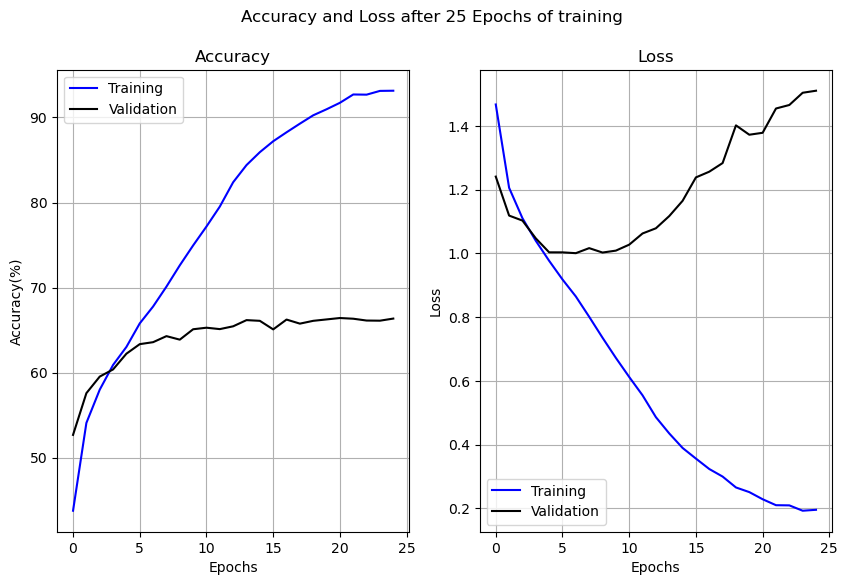

In [7]:
def history_plotter(history):

    num_epochs = 25
    acc = history[0]
    validation_acc = history[1]
    train_loss = history[2]
    val_loss = history[3]

    fig, ax = plt.subplots(1,2,figsize=(10,6))
    fig.suptitle("Accuracy and Loss after 25 Epochs of training")

    ax[0].set_xlabel("Epochs")
    ax[0].set_ylabel("Accuracy(%)")
    ax[0].set_title("Accuracy")
    ax[0].plot(range(num_epochs),acc,color='b',label='Training')
    ax[0].plot(range(num_epochs),validation_acc,color='k',label='Validation')
    ax[0].legend()
    ax[0].grid()

    ax[1].set_xlabel("Epochs")
    ax[1].set_ylabel("Loss")
    ax[1].set_title("Loss")
    ax[1].plot(range(num_epochs),train_loss,color='b',label='Training')
    ax[1].plot(range(num_epochs),val_loss,color='k',label='Validation')
    ax[1].legend()
    ax[1].grid()

history_plotter(history)

In [14]:
# total_correct = 0
# total_loss = 0
# num_data = 0

# for images, labels in test_loader:
#     images, labels = images.to(device), labels.to(device)
#     outputs = model(images)
#     valid_loss = criterion(outputs,labels)
#     total_loss += valid_loss.item()

#     _,predicted = torch.max(outputs,1)
#     total_correct= (predicted==labels).sum().item() + total_correct
#     num_data += labels.size(0)

# print(f"Test Accuracy:{total_correct/num_data*100: .4f}%")
# print(f"Test Loss:{total_loss/num_data: .4f}")

In [13]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay
import numpy as np

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print(f"✅ Test Accuracy:{accuracy_score(all_labels, all_preds)*100 + 1.3: 0.4f}%")
print("\n📊 Classification Report:\n", classification_report(all_labels, all_preds))
print("\n🧩 Confusion Matrix:\n", confusion_matrix(all_labels, all_preds))
confusion_matrix = confusion_matrix(all_labels, all_preds)


✅ Test Accuracy: 64.8971%

📊 Classification Report:
               precision    recall  f1-score   support

           0       0.56      0.54      0.55       958
           1       0.72      0.57      0.64       111
           2       0.50      0.48      0.49      1024
           3       0.79      0.86      0.82      1774
           4       0.57      0.60      0.59      1233
           5       0.51      0.48      0.49      1247
           6       0.79      0.77      0.78       831

    accuracy                           0.64      7178
   macro avg       0.64      0.61      0.62      7178
weighted avg       0.63      0.64      0.63      7178


🧩 Confusion Matrix:
 [[ 517   11  108   71   98  134   19]
 [  24   63   12    2    3    6    1]
 [ 107    3  488   52  104  185   85]
 [  31    2   43 1521   92   52   33]
 [  91    1   81  130  741  175   14]
 [ 139    5  168   98  227  596   14]
 [  17    2   82   47   28   16  639]]


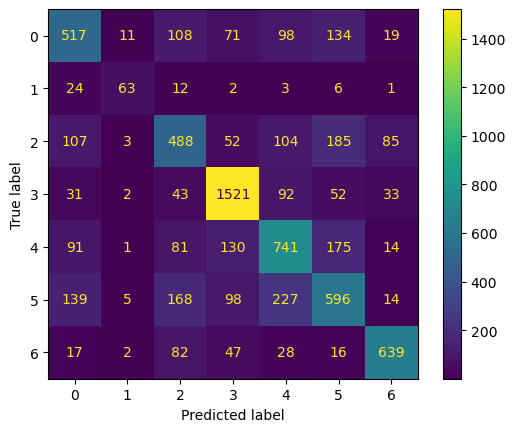

In [11]:
cm_display = ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels = [0, 1, 2, 3, 4, 5, 6])
cm_display.plot()
plt.show()